# Model 2: Extended Linear Regression With School Features

This notebook extends the baseline model by adding cleaned, regime-aware school-quality features.

- Unit of observation: one `zcta5` in one feature year `t`
- Target: `target_median_sale_price_log_change_next_year`
- Main evaluation: temporal split (`2012-2019` train, `2021-2023` validation)
- Secondary evaluation: grouped ZCTA split (unseen locations in test)

Notes:
- `2014` is absent because of the CST to CAASPP transition.
- `2020` is absent from school-quality data because of the COVID interruption.
- School-score features use within-assessment-year standardization to avoid treating CST and CAASPP raw scales as directly comparable.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
PROJECT_ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'model-ready').exists())
DATA_DIR = PROJECT_ROOT / 'model-ready'
listings_path = DATA_DIR / 'listings_model_ready.csv'
demographics_path = DATA_DIR / 'zcta_demographics_features.csv'
school_path = DATA_DIR / 'school_quality_features.csv'

assert listings_path.exists(), listings_path
assert demographics_path.exists(), demographics_path
assert school_path.exists(), school_path

In [3]:
listings = pd.read_csv(listings_path)
demographics = pd.read_csv(demographics_path)
school = pd.read_csv(school_path)

for frame in [listings, demographics, school]:
    frame['zcta5'] = frame['zcta5'].astype(str).str.zfill(5)

panel = listings.merge(
    demographics,
    on=['zcta5', 'year'],
    how='inner',
    validate='one_to_one',
)
panel = panel.merge(
    school,
    on=['zcta5', 'year'],
    how='inner',
    validate='one_to_one',
)

panel = panel[
    panel['baseline_model_eligible']
    & panel['demographics_baseline_eligible']
    & panel['school_quality_extended_eligible']
].copy()

panel = panel.sort_values(['year', 'zcta5']).reset_index(drop=True)
panel[['zcta5', 'year']].duplicated().sum()

np.int64(0)

In [4]:
print(f'Rows in extended panel: {len(panel):,}')
print(f'Unique ZCTAs: {panel["zcta5"].nunique():,}')
print(f'Year range: {panel["year"].min()}-{panel["year"].max()}')
print()
display(panel.groupby('year').size().rename('rows').to_frame())
display(panel.groupby(['year', 'assessment_type']).size().rename('rows').to_frame())
display(panel[['zcta5', 'year', 'assessment_type', 'target_median_sale_price_log_change_next_year']].head())

Rows in extended panel: 8,787
Unique ZCTAs: 1,250
Year range: 2012-2023



,rows
year,
2012,792
2013,865
2015,905
2016,915
2017,920
2018,932
2019,935
2021,657
2022,943


,,rows
year,assessment_type,
2012,CST,792
2013,CST,865
2015,CAASPP,905
2016,CAASPP,915
2017,CAASPP,920
2018,CAASPP,932
2019,CAASPP,935
2021,CAASPP,657
2022,CAASPP,943


,zcta5,year,assessment_type,target_median_sale_price_log_change_next_year
0,90001,2012,CST,0.211061
1,90002,2012,CST,0.263926
2,90003,2012,CST,0.231633
3,90004,2012,CST,0.371019
4,90005,2012,CST,0.113280


In [5]:
feature_columns = [
    'year',
    'annual_homes_sold',
    'annual_pending_sales',
    'annual_new_listings',
    'annual_inventory_mean',
    'annual_inventory_end',
    'annual_months_of_supply_est',
    'annual_median_sale_price',
    'annual_median_list_price',
    'annual_median_ppsf',
    'annual_median_list_ppsf',
    'annual_avg_sale_to_list',
    'annual_sold_above_list',
    'annual_off_market_in_two_weeks',
    'annual_median_dom',
    'log_total_population',
    'log_median_household_income',
    'median_household_income_missing',
    'age_0_17_share',
    'age_18_24_share',
    'age_25_34_share',
    'age_35_44_share',
    'age_45_64_share',
    'education_less_than_high_school_share',
    'education_some_college_or_associates_share',
    'education_bachelors_or_higher_share',
    'foreign_born_total_share',
    'native_born_other_state_us_share',
    'born_other_state_25plus_bachelors_or_higher_share',
    'foreign_born_25plus_bachelors_or_higher_share',
    'is_caaspp',
    'n_schools',
    'log1p_n_schools',
    'avg_pct_met_overall_z_assessment_year',
    'avg_pct_met_ela_z_assessment_year',
    'avg_pct_met_math_z_assessment_year',
    'median_pct_met_overall_z_assessment_year',
    'overall_score_range',
]

target_column = 'target_median_sale_price_log_change_next_year'

X = panel[feature_columns].copy()
X['median_household_income_missing'] = X['median_household_income_missing'].astype(int)
X['is_caaspp'] = X['is_caaspp'].astype(int)
y = panel[target_column].astype(float)

missing_summary = X.isna().sum().sort_values(ascending=False)
display(missing_summary[missing_summary > 0].to_frame('missing_rows'))

,missing_rows
avg_pct_met_math_z_assessment_year,23
log_median_household_income,9
avg_pct_met_ela_z_assessment_year,8
foreign_born_25plus_bachelors_or_higher_share,8
annual_median_dom,6
annual_median_list_ppsf,3
annual_new_listings,3
annual_median_list_price,3
born_other_state_25plus_bachelors_or_higher_share,1


In [6]:
def build_model():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LinearRegression()),
    ])


def evaluate_split(model, split_name, X_split, y_split):
    predictions = model.predict(X_split)
    metrics = pd.Series({
        'split': split_name,
        'rows': len(X_split),
        'rmse': mean_squared_error(y_split, predictions) ** 0.5,
        'mae': mean_absolute_error(y_split, predictions),
        'r2': r2_score(y_split, predictions),
    })
    return metrics, predictions

In [8]:
train_mask = panel['year'] <= 2019
valid_mask = panel['year'].between(2021, 2023)

X_train = X.loc[train_mask].copy()
X_valid = X.loc[valid_mask].copy()
y_train = y.loc[train_mask].copy()
y_valid = y.loc[valid_mask].copy()

print(f'Train rows: {len(X_train):,}')
print(f'Validation rows: {len(X_valid):,}')

temporal_model = build_model()
temporal_model.fit(X_train, y_train)

train_metrics, train_pred = evaluate_split(temporal_model, 'temporal_train', X_train, y_train)
valid_metrics, valid_pred = evaluate_split(temporal_model, 'temporal_validation', X_valid, y_valid)
temporal_metrics = pd.DataFrame([train_metrics, valid_metrics]).set_index('split')
display(temporal_metrics)

temporal_validation_results = panel.loc[valid_mask, ['zcta5', 'year', 'assessment_type']].copy()
temporal_validation_results['actual_log_change'] = y_valid.values
temporal_validation_results['predicted_log_change'] = valid_pred
temporal_validation_results['residual'] = (
    temporal_validation_results['actual_log_change'] - temporal_validation_results['predicted_log_change']
)
display(temporal_validation_results.head())

Train rows: 6,264
Validation rows: 2,523


,rows,rmse,mae,r2
split,,,,
temporal_train,6264,0.080870,0.049933,0.306590
temporal_validation,2523,0.085577,0.059906,-0.025376


,zcta5,year,assessment_type,actual_log_change,predicted_log_change,residual
6264,90001,2021,CAASPP,0.061736,0.075975,-0.014239
6265,90003,2021,CAASPP,0.081246,0.079651,0.001596
6266,90004,2021,CAASPP,0.073984,0.026961,0.047023
6267,90005,2021,CAASPP,0.080280,0.042440,0.037840
6268,90007,2021,CAASPP,0.197308,0.042330,0.154979


In [9]:
coef_table = pd.DataFrame({
    'feature': feature_columns,
    'coefficient': temporal_model.named_steps['model'].coef_,
})
coef_table['abs_coefficient'] = coef_table['coefficient'].abs()

display(coef_table.sort_values('abs_coefficient', ascending=False).head(20))

,feature,coefficient,abs_coefficient
7,annual_median_sale_price,-0.122586,0.122586
8,annual_median_list_price,0.099586,0.099586
10,annual_median_list_ppsf,0.096708,0.096708
9,annual_median_ppsf,-0.091480,0.091480
2,annual_pending_sales,0.073846,0.073846
3,annual_new_listings,-0.072142,0.072142
4,annual_inventory_mean,0.063459,0.063459
5,annual_inventory_end,-0.045694,0.045694
25,education_bachelors_or_higher_share,-0.025463,0.025463
30,is_caaspp,-0.019891,0.019891


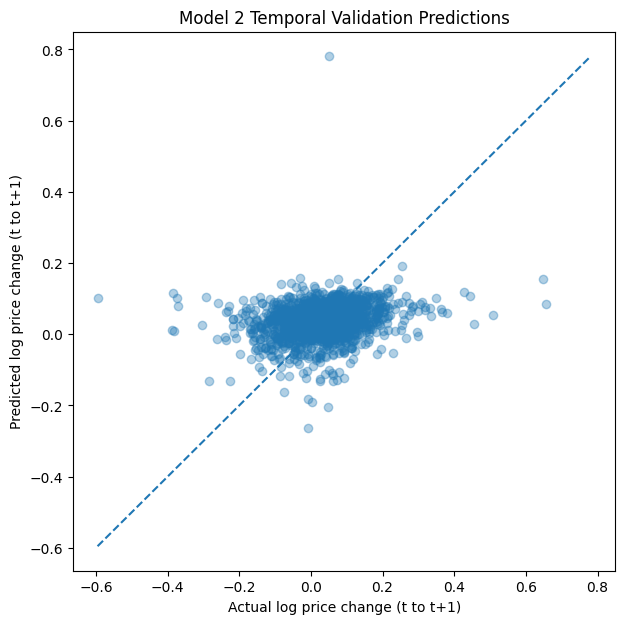

In [10]:
plt.figure(figsize=(7, 7))
plt.scatter(y_valid, valid_pred, alpha=0.35)
lims = [min(y_valid.min(), valid_pred.min()), max(y_valid.max(), valid_pred.max())]
plt.plot(lims, lims, linestyle='--')
plt.xlabel('Actual log price change (t to t+1)')
plt.ylabel('Predicted log price change (t to t+1)')
plt.title('Model 2 Temporal Validation Predictions')
plt.show()

## Secondary Evaluation: Grouped ZCTA Split

This split keeps all years for a given `zcta5` on one side of the train/test boundary.
It measures generalization to unseen locations, not forward-in-time forecasting.

In [11]:
group_splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
group_train_idx, group_test_idx = next(group_splitter.split(X, y, groups=panel['zcta5']))

X_group_train = X.iloc[group_train_idx].copy()
X_group_test = X.iloc[group_test_idx].copy()
y_group_train = y.iloc[group_train_idx].copy()
y_group_test = y.iloc[group_test_idx].copy()
panel_group_train = panel.iloc[group_train_idx].copy()
panel_group_test = panel.iloc[group_test_idx].copy()

print(f'Grouped train rows: {len(X_group_train):,}')
print(f'Grouped test rows: {len(X_group_test):,}')
print(f'Grouped train ZCTAs: {panel_group_train["zcta5"].nunique():,}')
print(f'Grouped test ZCTAs: {panel_group_test["zcta5"].nunique():,}')

grouped_model = build_model()
grouped_model.fit(X_group_train, y_group_train)

group_train_metrics, group_train_pred = evaluate_split(
    grouped_model,
    'grouped_zcta_train',
    X_group_train,
    y_group_train,
)
group_test_metrics, group_test_pred = evaluate_split(
    grouped_model,
    'grouped_zcta_test',
    X_group_test,
    y_group_test,
)
grouped_metrics = pd.DataFrame([group_train_metrics, group_test_metrics]).set_index('split')
display(grouped_metrics)

comparison = pd.concat([
    temporal_metrics.loc[['temporal_validation']],
    grouped_metrics.loc[['grouped_zcta_test']],
])
display(comparison)

display(panel_group_test.groupby(['year', 'assessment_type']).size().rename('grouped_test_rows').to_frame())

Grouped train rows: 7,036
Grouped test rows: 1,751
Grouped train ZCTAs: 1,000
Grouped test ZCTAs: 250


,rows,rmse,mae,r2
split,,,,
grouped_zcta_train,7036,0.081434,0.051459,0.314129
grouped_zcta_test,1751,0.079148,0.051752,0.264846


,rows,rmse,mae,r2
split,,,,
temporal_validation,2523,0.085577,0.059906,-0.025376
grouped_zcta_test,1751,0.079148,0.051752,0.264846


,,grouped_test_rows
year,assessment_type,
2012,CST,156
2013,CST,180
2015,CAASPP,184
2016,CAASPP,182
2017,CAASPP,179
2018,CAASPP,188
2019,CAASPP,193
2021,CAASPP,132
2022,CAASPP,178


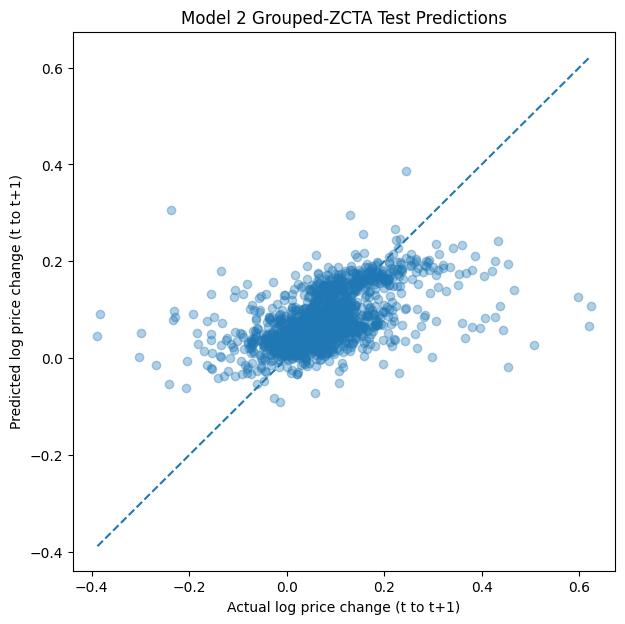

In [12]:
plt.figure(figsize=(7, 7))
plt.scatter(y_group_test, group_test_pred, alpha=0.35)
lims = [min(y_group_test.min(), group_test_pred.min()), max(y_group_test.max(), group_test_pred.max())]
plt.plot(lims, lims, linestyle='--')
plt.xlabel('Actual log price change (t to t+1)')
plt.ylabel('Predicted log price change (t to t+1)')
plt.title('Model 2 Grouped-ZCTA Test Predictions')
plt.show()